In [1]:
import mediapipe as mp
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [6]:
cap = cv2.VideoCapture("../data/silesian_deception_dataset/poli1Video/person1.avi")
cap.set(cv2.CAP_PROP_POS_MSEC, 3000)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Failed to read frame from video.")

h, w, _ = frame.shape
mp_face_mesh = mp.solutions.face_mesh

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True
) as face_mesh:

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = face_mesh.process(rgb)

    if not result.multi_face_landmarks:
        raise RuntimeError("No face detected")

    landmarks = result.multi_face_landmarks[0].landmark

print("Liczba landmarków:", len(landmarks))

points = [(lm.x * w, lm.y * h) for lm in landmarks]

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# siatka
for a, b in mp_face_mesh.FACEMESH_TESSELATION:
    x1, y1 = points[a]
    x2, y2 = points[b]
    plt.plot([x1, x2], [y1, y2], linewidth=0.3, alpha=0.6)

# punkty + indeksy
for i, (x, y) in enumerate(points):
    plt.scatter(x, y, s=4)
    plt.text(
        x + 1, y + 1,
        str(i),
        fontsize=5,
        alpha=0.7
    )

plt.axis("off")
plt.savefig(
    "../docs/wut-thesis/images/face_mesh_indices.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0
)
plt.close()

I0000 00:00:1767621827.353907       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro


Liczba landmarków: 478


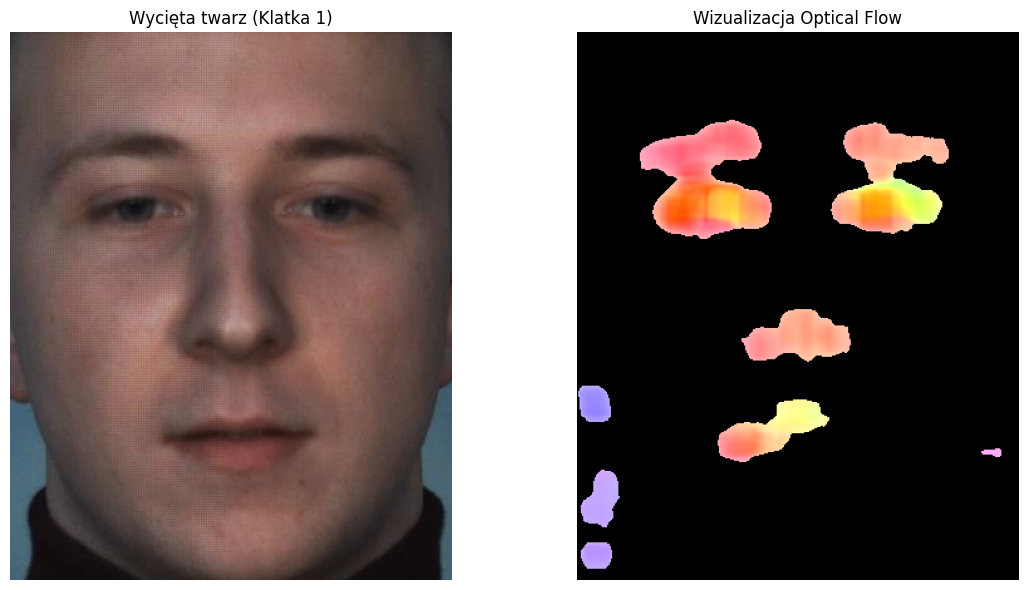

In [36]:
def detect_faces(model, frame):
    results = model(frame, verbose=False)
    if not results or results[0].boxes is None:
        return []
    return results[0].boxes.xyxy.int().tolist()

def face_crop(model, frame):
    boxes = detect_faces(model, frame)
    for _, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)
        h, w = frame.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        return crop, (x1, y1, x2, y2)
    return None, None

def generate_optical_flow_vis(model, frame1, frame2, output_prefix="../docs/wut-thesis/images/optical_flow"):
    crop1, coords = face_crop(model, frame1)
    
    if crop1 is None:
        print("Nie wykryto twarzy na pierwszej klatce.")
        return

    x1, y1, x2, y2 = coords
    crop2 = frame2[y1:y2, x1:x2]

    if crop1.shape != crop2.shape:
        crop2 = cv2.resize(crop2, (crop1.shape[1], crop1.shape[0]))

    prvs = cv2.cvtColor(crop1, cv2.COLOR_BGR2GRAY)
    next = cv2.cvtColor(crop2, cv2.COLOR_BGR2GRAY)

    prvs = cv2.GaussianBlur(prvs, (7, 7), 0)
    next = cv2.GaussianBlur(next, (7, 7), 0)

    flow = cv2.calcOpticalFlowFarneback(
        prev=prvs,
        next=next,
        flow=None,
        pyr_scale=0.5,
        levels=3,
        winsize=25,
        iterations=3,
        poly_n=7,
        poly_sigma=1.5,
        flags=0
    )

    hsv = np.zeros_like(crop1)
    hsv[..., 2] = 255

    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1], angleInDegrees=True)

    mask = abs(mag) < 1.0
    hsv[..., 0] = ang / 2
    hsv[..., 1] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    
    hsv[mask, 1] = 0 
    
    hsv[mask, 2] = 0 

    bgr_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    rgb_flow = cv2.cvtColor(bgr_flow, cv2.COLOR_BGR2RGB)
    rgb_crop1 = cv2.cvtColor(crop1, cv2.COLOR_BGR2RGB)

    path_orig = f"{output_prefix}_og.png"
    path_vis = f"{output_prefix}_vis.png"

    cv2.imwrite(path_orig, crop1)
    cv2.imwrite(path_vis, bgr_flow)

    plt.figure(figsize=(12, 6))
    plt.subplot(121)
    plt.imshow(rgb_crop1)
    plt.title("Wycięta twarz (Klatka 1)")
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(rgb_flow)
    plt.title("Wizualizacja Optical Flow")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

model = YOLO("../model_weights/yolov8n-face.pt") 
cap = cv2.VideoCapture("../data/silesian_deception_dataset/poli1Video/person4.avi")
cap.set(cv2.CAP_PROP_POS_MSEC, 50000)
ret, frame1 = cap.read()
for _ in range(10):
    ret, _ = cap.read()
ret, frame2 = cap.read()
cap.release()

if ret:
    generate_optical_flow_vis(model, frame1, frame2)

In [1]:
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

In [11]:
VIDEO_PATH = "../data/Real_life_Deception_Detection_Dataset/Test/trial_lie_058.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Nie udało się otworzyć wideo")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
current_frame_idx = 0

In [12]:
def get_frame(frame_idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def show_frame():
    clear_output(wait=True)
    frame = get_frame(current_frame_idx)
    if frame is None:
        print("Nie udało się wczytać klatki")
        return

    plt.figure(figsize=(8, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"Klatka {current_frame_idx + 1} / {total_frames}")
    plt.show()

    display(controls)

def next_frame(_):
    global current_frame_idx
    if current_frame_idx < total_frames - 1:
        current_frame_idx += 1
    show_frame()

def prev_frame(_):
    global current_frame_idx
    if current_frame_idx > 0:
        current_frame_idx -= 1
    show_frame()

def save_frame(_):
    frame = get_frame(current_frame_idx)
    if frame is None:
        print("Brak klatki do zapisu")
        return

    os.makedirs("frames", exist_ok=True)
    out_path = f"frames/frame_{current_frame_idx:06d}.png"
    cv2.imwrite(out_path, cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    print(f"Zapisano: {out_path}")

btn_prev = widgets.Button(description="◀ Poprzednia")
btn_next = widgets.Button(description="Następna ▶")
btn_save = widgets.Button(description="💾 Zapisz klatkę")

btn_prev.on_click(prev_frame)
btn_next.on_click(next_frame)
btn_save.on_click(save_frame)

controls = widgets.HBox([btn_prev, btn_next, btn_save])

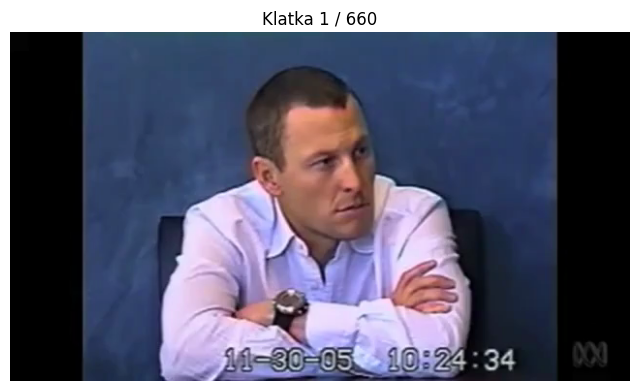

In [14]:
show_frame()